In [1]:
!pip install shap gradio requests -q

In [2]:
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import gradio as gr
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

warnings.filterwarnings("ignore")

In [3]:
print("Conectando à API do Open-Meteo para coleta de dados reais...")

biomas_coords = {
    "Amazonia": {"lat": -3.4653, "lon": -62.2159},
    "Cerrado": {"lat": -12.8275, "lon": -50.1583},
    "Caatinga": {"lat": -9.3930, "lon": -40.5050},
    "Pantanal": {"lat": -18.9950, "lon": -56.6230}
}

start_date = "2023-01-01"
end_date = "2023-12-31"
all_data = []

for bioma, coords in biomas_coords.items():
    print(f"Coletando dados da região: {bioma}...")
    url = (
        f"https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={coords['lat']}&longitude={coords['lon']}&"
        f"start_date={start_date}&end_date={end_date}&"
        f"daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration&"
        f"timezone=America%2FSao_Paulo"
    )

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        df_temp = pd.DataFrame(data['daily'])
        df_temp['Bioma'] = bioma
        all_data.append(df_temp)
    else:
        print(f"Erro ao coletar dados para {bioma}: {response.status_code}")

    time.sleep(1)

df = pd.concat(all_data, ignore_index=True)
df = df.rename(columns={
    "temperature_2m_max": "Temp_Max",
    "temperature_2m_min": "Temp_Min",
    "temperature_2m_mean": "Temp_Media",
    "precipitation_sum": "Precipitacao",
    "wind_speed_10m_max": "Velocidade_Vento",
    "wind_direction_10m_dominant": "Direcao_Vento",
    "shortwave_radiation_sum": "Radiacao_Solar",
    "et0_fao_evapotranspiration": "Evapotranspiracao"
})

print(f"\nColeta concluída! Formato do Dataset real: {df.shape}")

Conectando à API do Open-Meteo para coleta de dados reais...
Coletando dados da região: Amazonia...
Coletando dados da região: Cerrado...
Coletando dados da região: Caatinga...
Coletando dados da região: Pantanal...

Coleta concluída! Formato do Dataset real: (1460, 10)


In [4]:
df = df.dropna().copy()

df['Choveu'] = (df['Precipitacao'] > 0).astype(int)
m = df['Choveu'] == 0
df['Dias_Sem_Chuva'] = m.groupby((~m).cumsum()).cumsum()

risco_score = (df['Temp_Max'] * 0.4) + (df['Dias_Sem_Chuva'] * 0.3) + (df['Velocidade_Vento'] * 0.2) + (df['Evapotranspiracao'] * 0.5)
limiar_perigo = np.percentile(risco_score, 70)
df['Risco_Incendio'] = (risco_score > limiar_perigo).astype(int)

df = df.drop(columns=['time', 'Choveu', 'Precipitacao'])

X = df.drop('Risco_Incendio', axis=1)
y = df['Risco_Incendio']

X = pd.get_dummies(X, columns=['Bioma'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
pred_log = log_model.predict(X_test_scaled)
acc_log = accuracy_score(y_test, pred_log)

print("\n--- PERFORMANCE: REGRESSÃO LOGÍSTICA ---")
print(f"Acurácia: {acc_log:.2f}")
print(classification_report(y_test, pred_log))


--- PERFORMANCE: REGRESSÃO LOGÍSTICA ---
Acurácia: 0.99
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       205
           1       0.99      0.98      0.98        87

    accuracy                           0.99       292
   macro avg       0.99      0.99      0.99       292
weighted avg       0.99      0.99      0.99       292




--- PERFORMANCE: RANDOM FOREST ---
Acurácia: 0.98
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       205
           1       1.00      0.92      0.96        87

    accuracy                           0.98       292
   macro avg       0.98      0.96      0.97       292
weighted avg       0.98      0.98      0.98       292



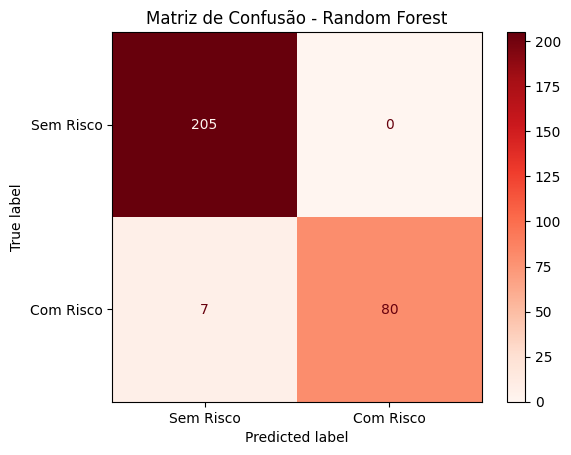

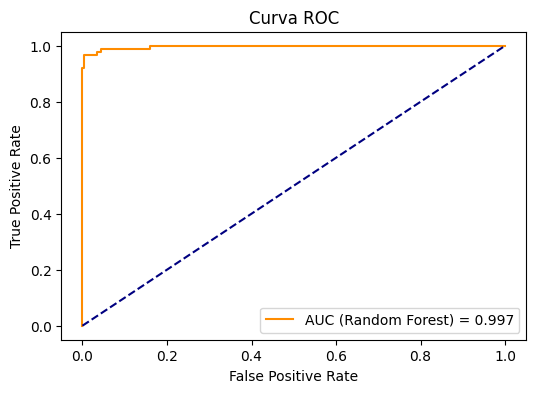

In [6]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

print("\n--- PERFORMANCE: RANDOM FOREST ---")
print(f"Acurácia: {acc_rf:.2f}")
print(classification_report(y_test, pred_rf))

cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sem Risco', 'Com Risco'])
disp.plot(cmap=plt.cm.Reds)
plt.title("Matriz de Confusão - Random Forest")
plt.show()

probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC (Random Forest) = {auc:.3f}', color='darkorange')
plt.plot([0, 1], [0, 1], '--', color='navy')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


Calculando valores SHAP para interpretabilidade (Árvores de Decisão)...


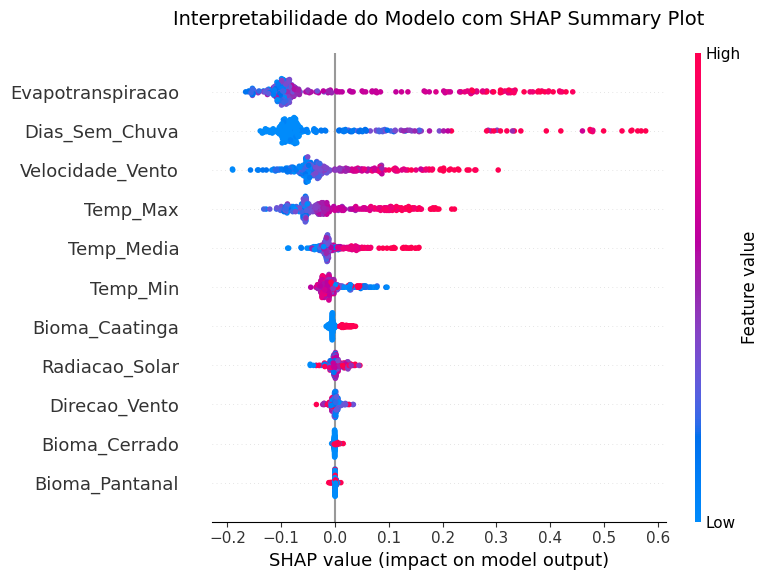

In [7]:
print("\nCalculando valores SHAP para interpretabilidade (Árvores de Decisão)...")

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

if len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.title("Interpretabilidade do Modelo com SHAP Summary Plot", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [8]:
feature_columns = list(X_train.columns)

def predizer_risco(temp_max, temp_min, temp_media, vento_vel, vento_dir, rad, evap, bioma_nome):
    bioma_caatinga = 1.0 if bioma_nome == 'Caatinga' else 0.0
    bioma_cerrado = 1.0 if bioma_nome == 'Cerrado' else 0.0
    bioma_pantanal = 1.0 if bioma_nome == 'Pantanal' else 0.0

    dias_sem_chuva = 15.0

    features = pd.DataFrame([[
        temp_max, temp_min, temp_media, vento_vel, vento_dir, rad, evap,
        dias_sem_chuva, bioma_caatinga, bioma_cerrado, bioma_pantanal
    ]], columns=feature_columns)

    predicao = rf_model.predict(features)[0]
    probabilidade = rf_model.predict_proba(features)[0][1]

    if predicao == 1:
        return f"🚨 ALERTA CRÍTICO: Alto Risco de Incêndio na Região! (Probabilidade: {probabilidade:.2%})"
    else:
        return f"✅ CONDIÇÃO SEGURA: Baixo Risco de Incêndio detetado. (Probabilidade: {probabilidade:.2%})"

interface = gr.Interface(
    fn=predizer_risco,
    inputs=[
        gr.Slider(minimum=15, maximum=48, value=36, label="Temperatura Máxima (°C)"),
        gr.Slider(minimum=5, maximum=30, value=22, label="Temperatura Mínima (°C)"),
        gr.Slider(minimum=10, maximum=40, value=29, label="Temperatura Média (°C)"),
        gr.Slider(minimum=0, maximum=70, value=20, label="Velocidade Máxima do Vento (km/h)"),
        gr.Slider(minimum=0, maximum=360, value=120, label="Direção Dominante do Vento (Graus 0-360)"),
        gr.Slider(minimum=0, maximum=35, value=18, label="Radiação Solar Curta (MJ/m²)"),
        gr.Slider(minimum=0, maximum=15, value=6.5, label="Evapotranspiração de Referência FAO (mm/dia)"),
        gr.Dropdown(choices=['Amazonia', 'Cerrado', 'Caatinga', 'Pantanal'], value='Cerrado', label="Bioma Alvo para Análise")
    ],
    outputs=gr.Textbox(label="Análise do Modelo Preditivo (Random Forest)"),
    title="GS 2026 - GAIE: Sistema de Monitoramento Orbital de Queimadas",
    description="Insira as variáveis climáticas capturadas via satélite (Open-Meteo API) para calcular a probabilidade real de focos de incêndio florestal na Economia Espacial."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c69f5c6280eac32d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
